# 日内波动建模：结果浏览

方法讨论先读[符号约定与推导](research/03_method_derivations.md)，文献依据见[跨文献核对](literature/notes/07_notation_survey.md)。实证结果见 [FINAL_REPORT.md](FINAL_REPORT.md)。下列单元只读已有结果，不重跑模型；完整复现命令见根README。请将Notebook工作目录设为本项目根。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
from data_contracts import MINUTE_OBSERVATION_SCHEMA, PERIODICITY_FACTOR_SCHEMA
project_dir = Path.cwd()
assert (project_dir / 'FINAL_REPORT.md').exists(), '请在独立项目根运行'
for artifact_schema in (MINUTE_OBSERVATION_SCHEMA, PERIODICITY_FACTOR_SCHEMA):
    display(pd.DataFrame([{'field': f.name, 'arrow_type': str(f.type), 'nullable': f.nullable} for f in artifact_schema]))
    display({key.decode(): value.decode() for key, value in artifact_schema.metadata.items()})

,field,arrow_type,nullable
0,trading_date,date32[day],False
1,minute_index,int16,False
2,session_number,int8,False
3,bar_at,"timestamp[us, tz=Asia/Shanghai]",False
4,contract_code,string,False
5,log_return,double,True
6,rv_contribution,double,True
7,bpv_contribution,double,True
8,mixed_contribution,double,True


{'table_name': 'minute_observations',
 'primary_key': 'trading_date,minute_index',
 'return_definition': 'Session first minute log(close/open); else contiguous log(close/previous_close)',
 'bpv_definition': 'pi/2 * abs(r_m*r_previous); session first minute null',
 'mixed_definition': 'RV at session first minute; BPV otherwise',
 'units': 'Log return and squared log-return contributions; float64',
 'available_at': 'bar_at'}

,field,arrow_type,nullable
0,trading_date,date32[day],False
1,minute_index,int16,False
2,method,string,False
3,lookback_days,int16,False
4,variance_factor,double,True
5,contribution_factor,double,True
6,factor_fit_end_date,date32[day],True


{'table_name': 'periodicity_factors',
 'primary_key': 'trading_date,minute_index,method,lookback_days',
 'variance_factor': 'Mean-one return variance factor; median_mixed is a contribution-shape compatibility baseline only',
 'contribution_factor': 'First slot a_m; other slots sqrt(a_m*a_previous). median_mixed uses its direct shape instead',
 'fit_cutoff': 'All fitted data strictly precede trading_date; none is constant one',
 'missing': 'Warmup, incomplete training window or degenerate scale => Arrow null'}

## 数据与因子覆盖
Schema来自本项目唯一可执行定义，结果由脚本实际计算。

In [2]:
display(pd.read_csv(project_dir / 'results/factor_coverage.csv'))

,method,lookback_days,total_days,valid_days,warmup_days,degenerate_days,state_pooled_fallback_days
0,none,0,995,995,0,0,0
1,mean_rv,30,995,965,30,0,0
2,mean_rv,60,995,935,60,0,0
3,mean_rv,120,995,875,120,0,0
4,mean_rv,360,995,635,360,0,0
5,median_rv,30,995,965,30,0,0
6,median_rv,60,995,935,60,0,0
7,median_rv,120,995,875,120,0,0
8,median_rv,360,995,635,360,0,0
9,median_mixed,30,995,965,30,0,0


## 模拟、分布与状态
模拟反映指定机制，实证分布图属于描述性研究，不代替原文正式检验。

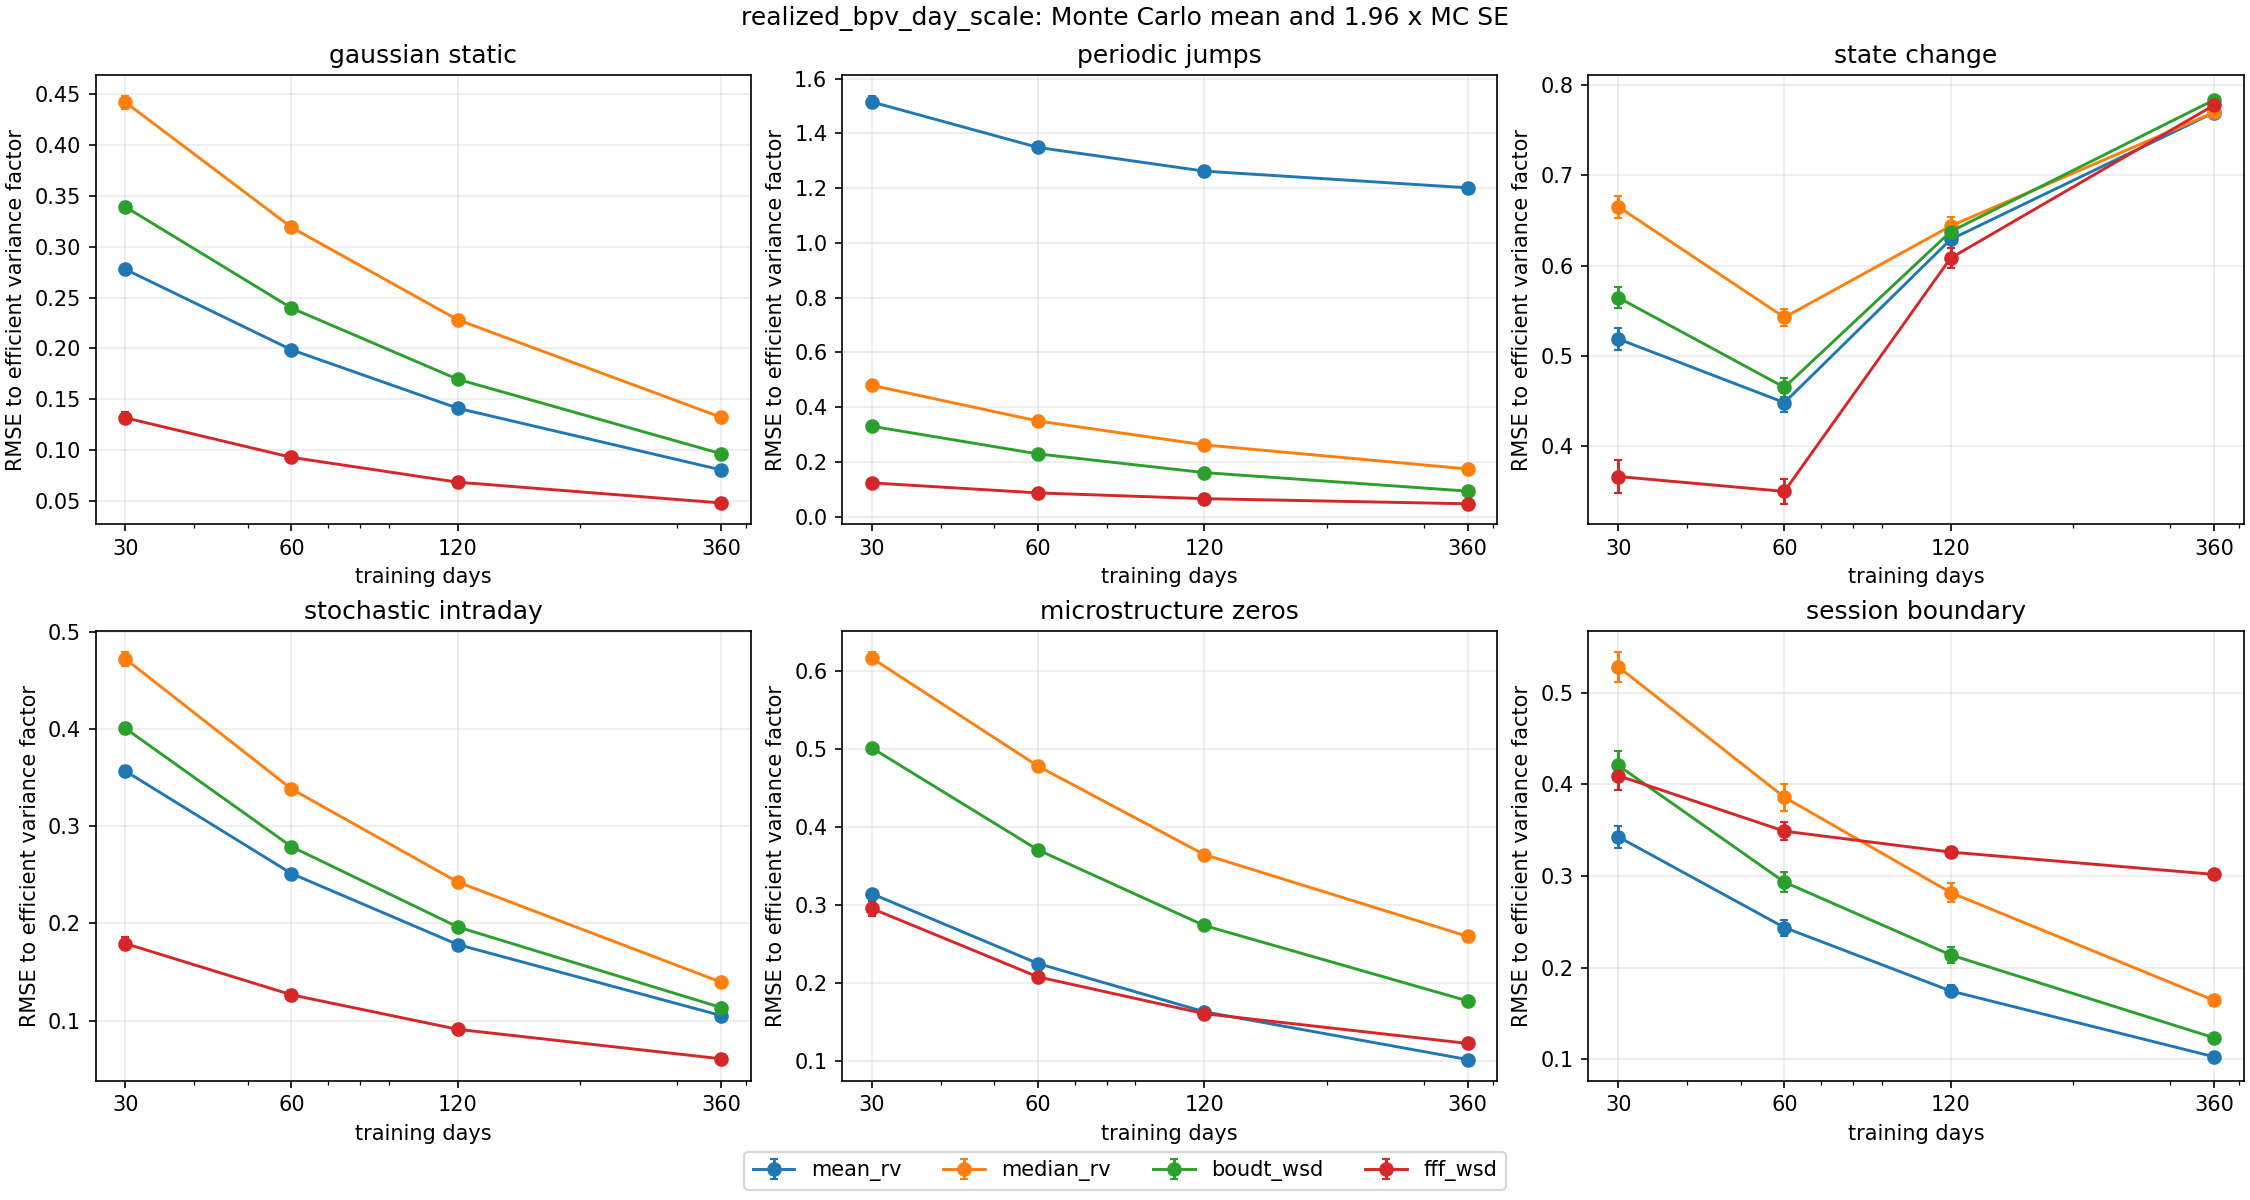

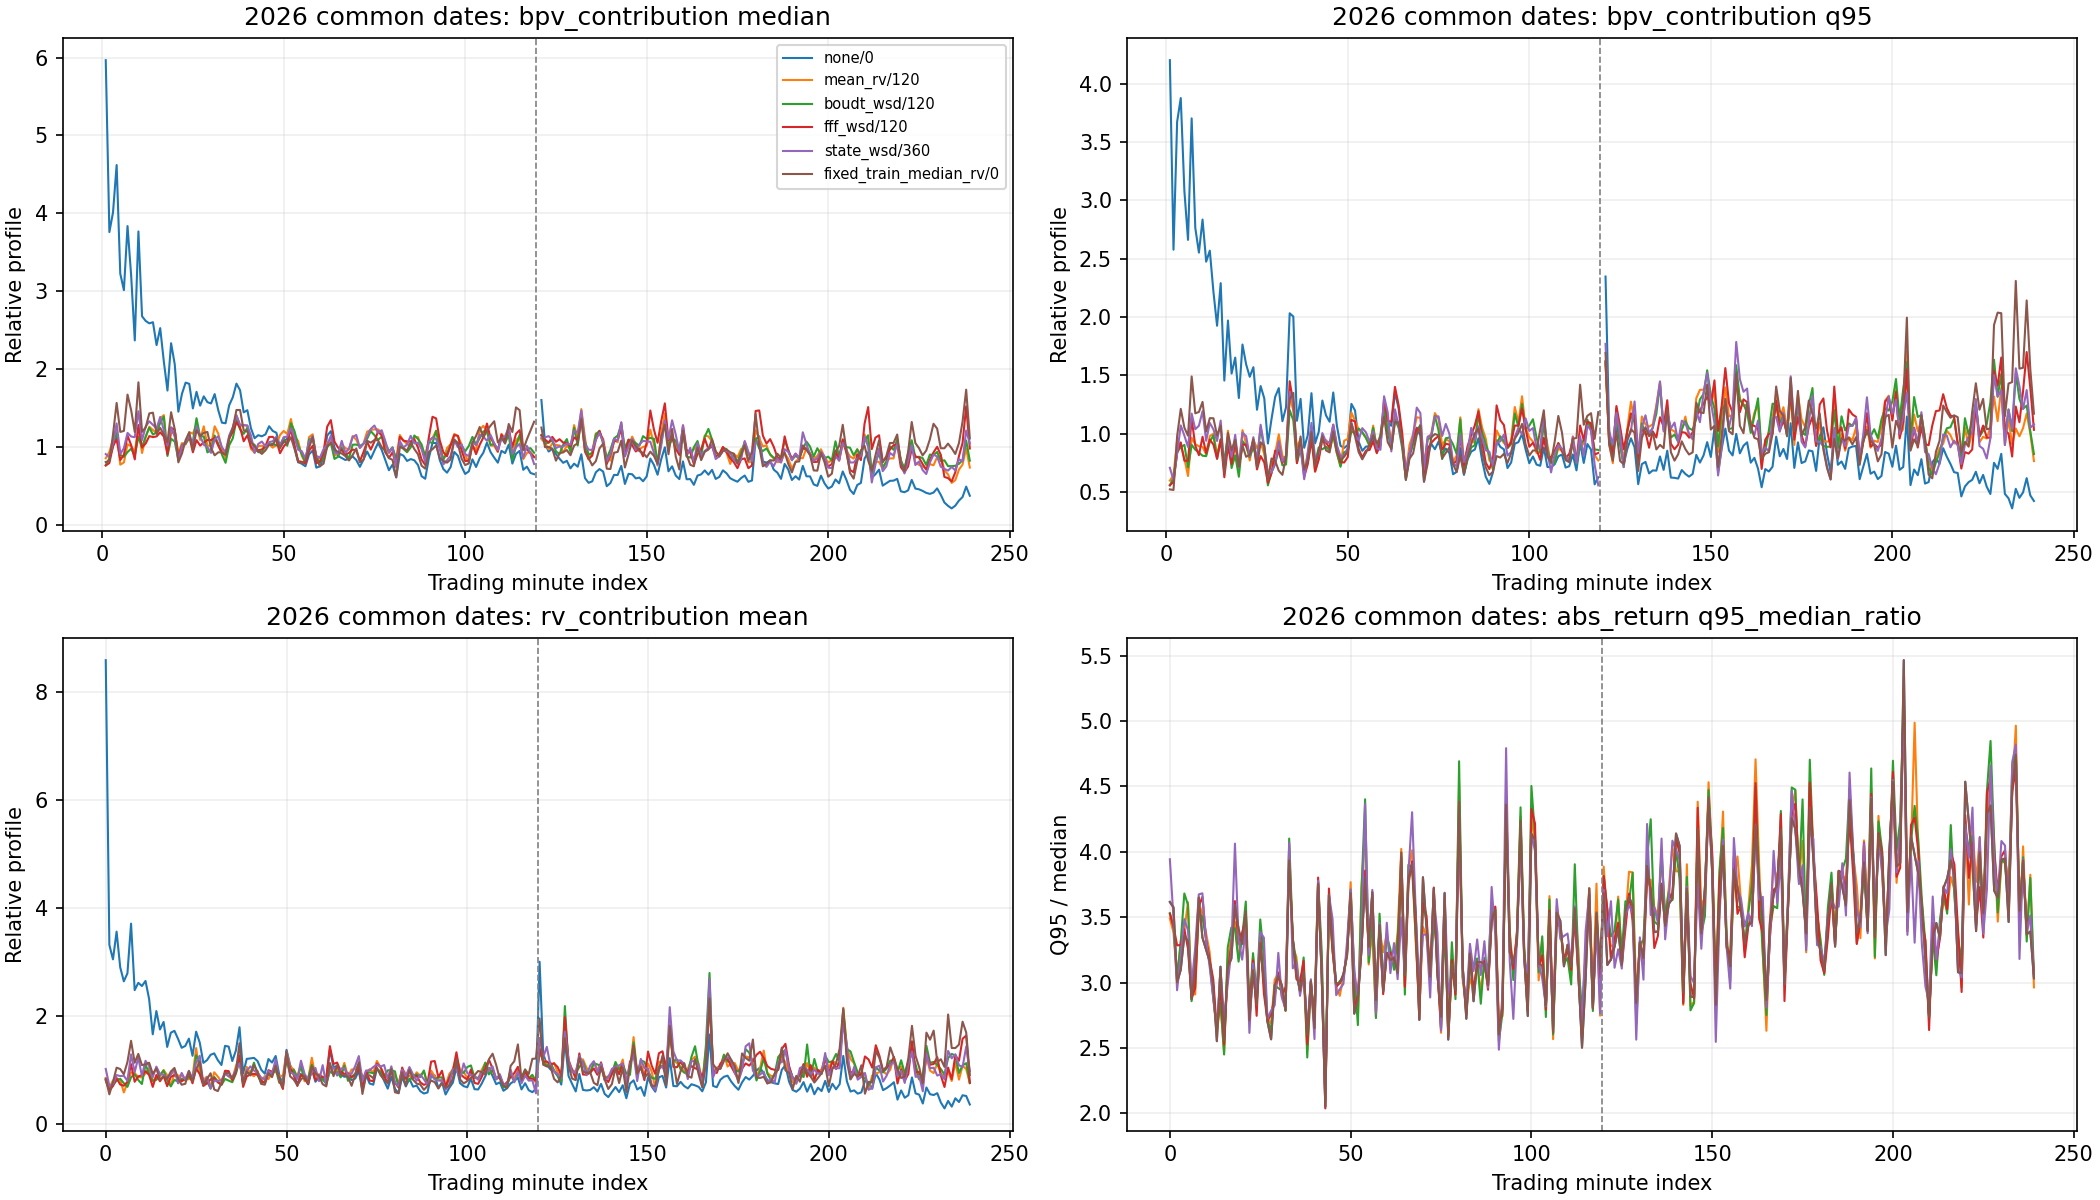

In [3]:
display(Image(filename=str(project_dir / 'results/simulations/factor_rmse_realized_bpv_day_scale.png')))
display(Image(filename=str(project_dir / 'results/diagnostics/distribution_profiles_2026.png')))

## 验证选窗后的2026回顾预测
2026并非未被观察的测试期；QLIKE负差表示优于同预测器无周期基准。

,model,method,lookback_days,qlike_difference_vs_none,qlike_difference_ci_low,qlike_difference_ci_high,mse_ratio_vs_none
268,ridge_intraday,boudt_wsd,360,-0.014331,-0.021775,-0.009718,0.879965
276,ridge_intraday,fff_wsd,360,-0.013873,-0.021268,-0.009328,0.876089
284,ridge_intraday,mean_rv,360,-0.013009,-0.020161,-0.008471,0.890910
292,ridge_intraday,median_mixed,360,-0.013420,-0.020946,-0.009075,0.897649
296,ridge_intraday,median_rv,360,-0.013667,-0.021293,-0.009173,0.884956
300,ridge_intraday,none,0,0.000000,0.000000,0.000000,1.000000
304,ridge_intraday,state_wsd,360,-0.012890,-0.019529,-0.007941,0.878006
312,scale_exposure,boudt_wsd,360,-0.031595,-0.049940,-0.013531,0.972177
316,scale_exposure,fff_wsd,30,-0.027790,-0.050503,-0.005016,1.004561
328,scale_exposure,mean_rv,360,-0.030790,-0.049544,-0.013372,0.973083


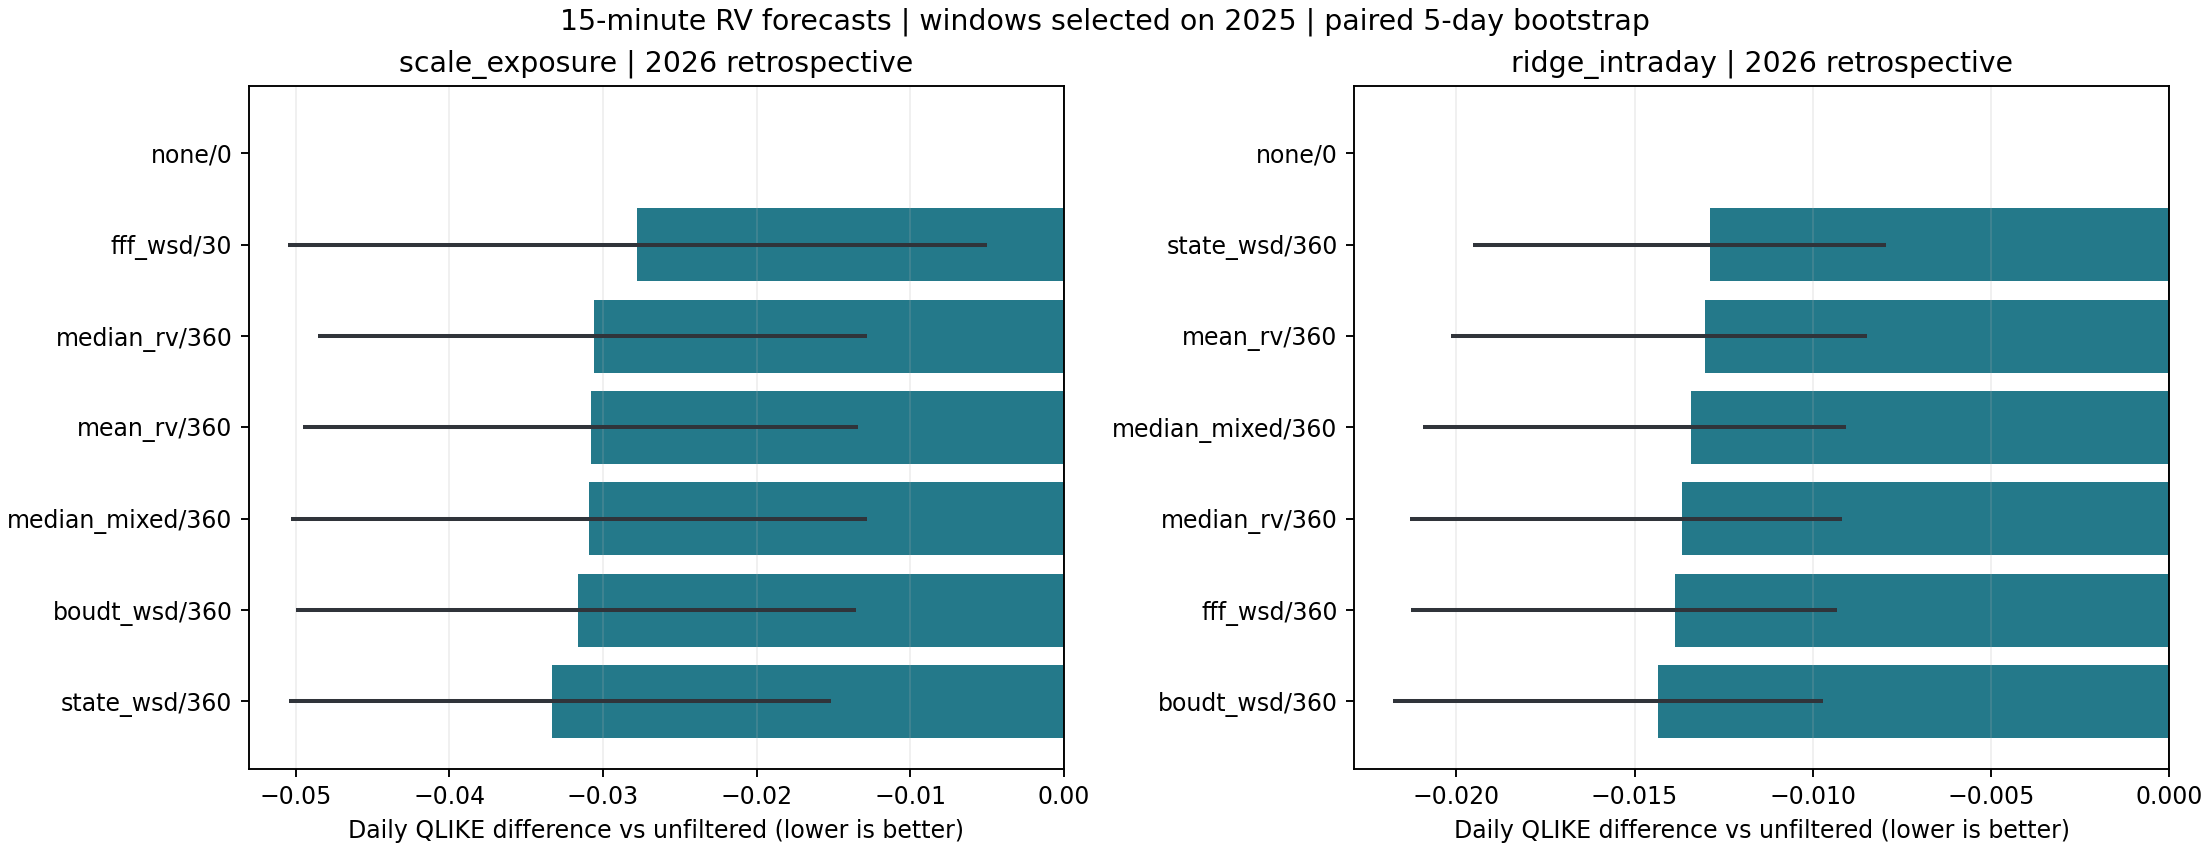

In [4]:
forecast_summary_df = pd.read_csv(project_dir / 'results/forecasting/forecast_summary.csv')
display(forecast_summary_df[(forecast_summary_df.year == 2026) & (forecast_summary_df.state == 'all') & (forecast_summary_df.target == 'RV15') & forecast_summary_df.selected_on_2025][['model','method','lookback_days','qlike_difference_vs_none','qlike_difference_ci_low','qlike_difference_ci_high','mse_ratio_vs_none']])
display(Image(filename=str(project_dir / 'results/forecasting/forecast_qlike_comparison.png')))

## 时钟与日级负结果
事件数稳定可能是构造性质；日级HARP未出现一致改善。

,year,model,horizon_days,days,qlike,mse,qlike_difference_vs_har,qlike_difference_ci_low,qlike_difference_ci_high
0,2025,HARP_WSD120_ridge_252,1,243,10.473011,1.068865e-08,0.012802,0.005059,0.022654
1,2025,HAR_ridge_252,1,243,10.460210,9.967911e-09,0.000000,0.000000,0.000000
2,2026,HARP_WSD120_ridge_252,1,159,10.961936,3.451398e-08,0.002350,-0.013751,0.022892
3,2026,HAR_ridge_252,1,159,10.959586,3.373817e-08,0.000000,0.000000,0.000000
4,2025,HARP_WSD120_ridge_252,5,239,10.562246,1.229095e-08,0.004357,-0.001179,0.009695
5,2025,HAR_ridge_252,5,239,10.557889,1.296941e-08,0.000000,0.000000,0.000000
6,2026,HARP_WSD120_ridge_252,5,155,11.074870,2.504244e-08,-0.004409,-0.017737,0.003873
7,2026,HAR_ridge_252,5,155,11.079278,2.463365e-08,0.000000,0.000000,0.000000
8,2025,HARP_WSD120_ridge_252,22,222,10.664252,1.583259e-08,0.000454,-0.002139,0.003060
9,2025,HAR_ridge_252,22,222,10.663797,1.609894e-08,0.000000,0.000000,0.000000


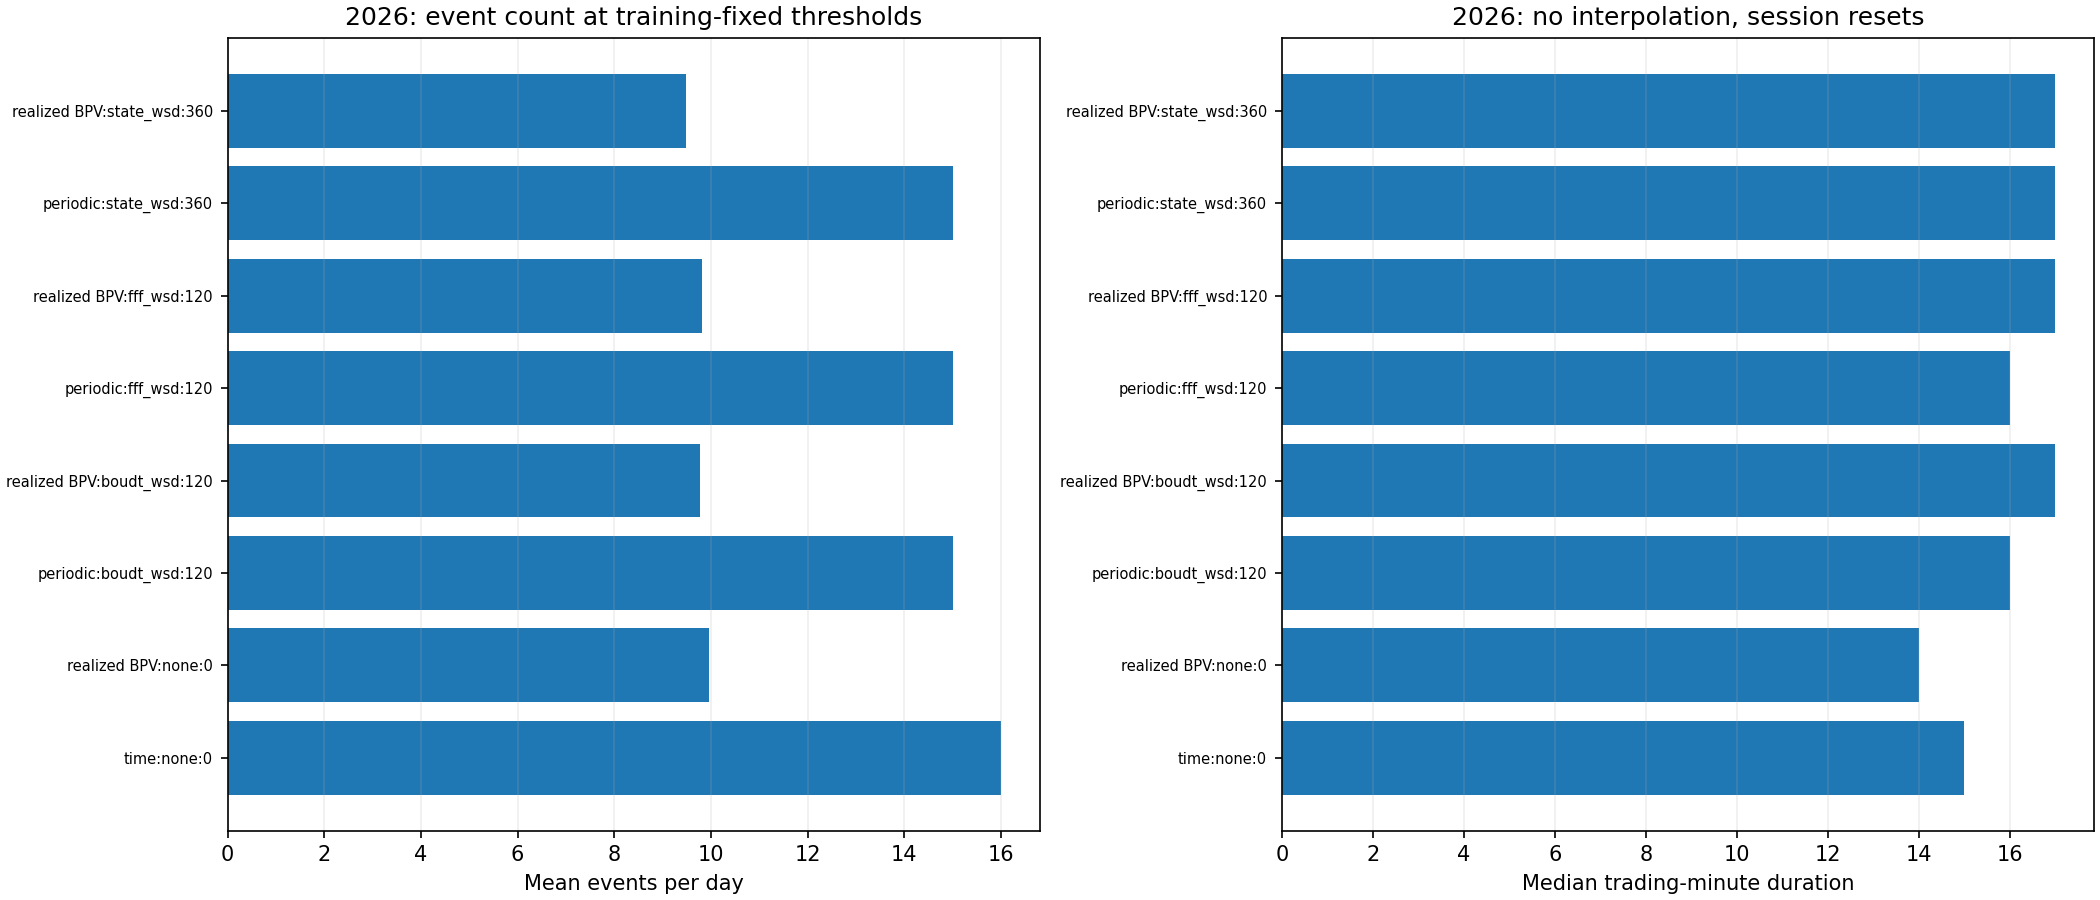

In [5]:
display(pd.read_csv(project_dir / 'results/forecasting/daily_har_summary.csv'))
display(Image(filename=str(project_dir / 'results/clocks/clock_comparison_2026.png')))